In [41]:
import os
path_project = os.path.dirname(os.path.abspath('.'))
import sys
sys.path.append(os.path.join(path_project, 'src'))
sys.path.append(os.path.join(path_project, 'exp/script'))
import results_saver
import options
import copy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import utility_experiment
import json
import subprocess
import re

img_path = os.path.join(path_project, 'exp', 'img')
results_path = os.path.join(path_project, 'exp', 'results')
default_args = options.build_default_args(path_project)

PLOT_MARKERS = ['o', 'v', 's', 'X', 'p', '*', 'h', '^', '<', '>', 'H', 'D', 'd', 'P']
METHOD_ORDER = ["DEFAULT", "ULDP-NAIVE", "ULDP-GROUP-2", "ULDP-GROUP-8", "ULDP-SGD", "ULDP-AVG"]

In [59]:
marker_size = 2
alpha = 0.9
import glob

def load_result_from_file_path(file_path: str):
    with open(file_path, "r") as json_file:
        results = json.load(json_file)
    args = results["args"]
    print(args)
    return results["exp"]

def plot_metric_per_method_by_filename(file_path: str):
    utility_metric_results = {"round_idx": [], "test_metric": [], "method": []}
    loss_metric_results = {"round_idx": [], "test_loss": [], "method": []}
    exp_result_list = load_result_from_file_path(file_path=file_path)
    global_test_list = []
    for exp_result in exp_result_list:
        global_test_list.extend(exp_result["global_test"])
    dir_name = os.path.dirname(file_path)
    for round_idx, test_metric, test_loss in global_test_list:
        utility_metric_results["round_idx"].append(round_idx)
        utility_metric_results["test_metric"].append(test_metric)
        utility_metric_results["method"].append("method")
        loss_metric_results["round_idx"].append(round_idx)
        loss_metric_results["test_loss"].append(test_loss)
        loss_metric_results["method"].append("method")

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="test_metric",
        data=utility_metric_results,
        ax=ax,
        markers=PLOT_MARKERS,
        markersize=marker_size,
        alpha=alpha,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("Metric", fontsize=18)
    ax.set_title(f"Metric over rounds", fontsize=20)
    fig.savefig(
        os.path.join(dir_name, "global_test_acc_per_method.png"),
        dpi=150,
        bbox_inches="tight",
    )

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="test_loss",
        data=loss_metric_results,
        ax=ax,
        markers=PLOT_MARKERS,
        markersize=marker_size,
        alpha=alpha,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("test loss", fontsize=18)
    ax.set_title(f"Test loss over rounds", fontsize=20)
    fig.savefig(
        os.path.join(dir_name, "global_test_loss_per_method.png"),
        dpi=150,
        bbox_inches="tight",
    )


def plot_epsilon_per_method_by_file_path(file_path: str):
    privacy_results = {"round_idx": [], "epsilon": [], "method": []}
    privacy_budget_list = load_result_from_file_path(file_path=file_path)
    dir_name = os.path.dirname(file_path)
    for round_idx, eps, _ in privacy_budget_list[0]["privacy_budget"]:
        privacy_results["round_idx"].append(round_idx)
        privacy_results["epsilon"].append(eps)
        privacy_results["method"].append("method")

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="epsilon",
        data=privacy_results,
        alpha=alpha,
        ax=ax,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("epsilon", fontsize=18)
    ax.set_title(f"Epsilon over rounds", fontsize=20)
    fig.savefig(
        os.path.join(dir_name, "global_epsilon.png"),
        dpi=150,
        bbox_inches="tight",
    )


def plot_multiple_epsilons(file_paths: list[str], setting_map: dict =None):
    n_files = len(file_paths)
    all_data = []
    for i, file_path in enumerate(file_paths):
        privacy_budget_list = load_result_from_file_path(file_path)
        all_data.append((i, privacy_budget_list[0]["privacy_budget"]))
    
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    if setting_map is None:
        setting_map = {i: i for i in range(n_files)}
    loss_metric_results = {"round_idx": [], "epsilon": [], "setting": []}
    for file_idx, result in all_data:
        for round_idx, epsilon, _  in result:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["epsilon"].append(epsilon)
            loss_metric_results["setting"].append(setting_map[file_idx])

    sns.lineplot(
        x="round_idx",
        y="epsilon",
        hue="setting",
        data=loss_metric_results,
        ax=ax,
        marker='o',
        markersize=4,
        alpha=1.0,
        palette="colorblind",
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("epsilon", fontsize=18)


def plot_multiple_losses(file_paths: list[str], setting_map: dict =None):
    n_files = len(file_paths)
    all_data = []
    for i, file_path in enumerate(file_paths):
        exp_result_list = load_result_from_file_path(file_path)
        global_test_list = []
        for exp_result in exp_result_list:
            global_test_list.extend(exp_result["global_test"])
            all_data.append((i, exp_result["global_test"]))
        loss_metric_results = {"round_idx": [], "test_loss": []}
        for round_idx, _, test_loss in global_test_list:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_loss"].append(test_loss)
    
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    if setting_map is None:
        setting_map = {i: i for i in range(n_files)}
    loss_metric_results = {"round_idx": [], "test_loss": [], "setting": []}
    for file_idx, result in all_data:
        for round_idx, _, test_loss in result:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_loss"].append(test_loss)
            loss_metric_results["setting"].append(setting_map[file_idx])

    sns.lineplot(
        x="round_idx",
        y="test_loss",
        hue="setting",
        data=loss_metric_results,
        ax=ax,
        marker='o',
        markersize=4,
        alpha=1.0,
        palette="colorblind",
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_yscale("log")
    ax.set_ylabel("test loss", fontsize=18)


def plot_multiple_metrics(file_paths: list[str], setting_map: dict =None):
    n_files = len(file_paths)
    all_data = []
    for i, file_path in enumerate(file_paths):
        exp_result_list = load_result_from_file_path(file_path)
        global_test_list = []
        for exp_result in exp_result_list:
            global_test_list.extend(exp_result["global_test"])
            all_data.append((i, exp_result["global_test"]))
        loss_metric_results = {"round_idx": [], "test_metric": []}
        for round_idx, test_metric, _ in global_test_list:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_metric"].append(test_metric)
    
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    if setting_map is None:
        setting_map = {i: i for i in range(n_files)}
    loss_metric_results = {"round_idx": [], "test_metric": [], "setting": []}
    for file_idx, result in all_data:
        for round_idx, test_metric, _ in result:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_metric"].append(test_metric)
            loss_metric_results["setting"].append(setting_map[file_idx])

    sns.lineplot(
        x="round_idx",
        y="test_metric",
        hue="setting",
        data=loss_metric_results,
        ax=ax,
        marker='o',
        markersize=4,
        alpha=1.0,
        palette="colorblind",
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("Metric", fontsize=18)
    

def plot_mpc_overhead(file_paths: list[str], setting_map: dict =None):
    n_files = len(file_paths)
    all_data = []
    for i, file_path in enumerate(file_paths):
        exp_result_list = load_result_from_file_path(file_path)
        global_test_list = []
        for exp_result in exp_result_list:
            global_test_list.extend(exp_result["global_test"])
            all_data.append((i, exp_result["global_test"]))
        loss_metric_results = {"round_idx": [], "test_metric": []}
        for round_idx, test_metric, _ in global_test_list:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_metric"].append(test_metric)
    
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    if setting_map is None:
        setting_map = {i: i for i in range(n_files)}
    loss_metric_results = {"round_idx": [], "test_metric": [], "setting": []}
    for file_idx, result in all_data:
        for round_idx, test_metric, _ in result:
            loss_metric_results["round_idx"].append(round_idx)
            loss_metric_results["test_metric"].append(test_metric)
            loss_metric_results["setting"].append(setting_map[file_idx])

    sns.lineplot(
        x="round_idx",
        y="test_metric",
        hue="setting",
        data=loss_metric_results,
        ax=ax,
        marker='o',
        markersize=4,
        alpha=1.0,
        palette="colorblind",
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("Metric", fontsize=18)


def get_file_path_from_hash(hash_val):
    files = glob.glob(os.path.join(results_path, hash_val, "*.json"))
    for f_path in files:
        print(f_path)
    return files

def extract_hash_from_script(script_name):
    script_path = f"{path_project}/exp/script/{script_name}.sh"
    process = subprocess.Popen(["bash", script_path, "--dry_run"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    stdout, stderr = process.communicate()
    stdout = stdout.decode("utf-8")
    stderr = stderr.decode("utf-8")
    print(stderr)
    hash_values = re.findall(r'Hash value:\s+([a-f0-9]+)', stdout)
    return hash_values

def get_result_files_of_script(script_name):
    hash_values = extract_hash_from_script(script_name)
    file_paths = []
    for h in hash_values:
        files = get_file_path_from_hash(h)
        sorted_files = sorted(files)
        file_paths.append(files[-1])
    return file_paths

## Overhead of MPC
- heart_disease
- tcga_brca

In [57]:
hash_values = extract_hash_from_script("secure_weighting")
file_paths = []
for h in hash_values:
    file_paths.extend(get_file_path_from_hash(h))
print(file_paths)

n_files = len(file_paths)
all_data = []
for i, file_path in enumerate(file_paths):
    exp_result_list = load_result_from_file_path(file_path)
    global_test_list = []
    for exp_result in exp_result_list:
        global_test_list.extend(exp_result["global_test"])
        all_data.append((i, exp_result["global_test"]))
    loss_metric_results = {"round_idx": [], "test_metric": []}
    for round_idx, test_metric, _ in global_test_list:
        loss_metric_results["round_idx"].append(round_idx)
        loss_metric_results["test_metric"].append(test_metric)

+++ dirname /Users/fumiyuki/research/AcSilo/acsilo/exp/script/secure_weighting.sh
++ cd /Users/fumiyuki/research/AcSilo/acsilo/exp/script
++ pwd -P
+ SCRIPT_PATH=/Users/fumiyuki/research/AcSilo/acsilo/exp/script
+ RUN_SIMULATION_PATH=/Users/fumiyuki/research/AcSilo/acsilo/exp/script/../../src/run_simulation.py
+ VERSION=0
+ TIMES=5
+ DRY_RUN=
+ for arg in '"$@"'
+ '[' --dry_run == --dry_run ']'
+ DRY_RUN=--dry_run
+ n_users_list=(10 100)
+ for n_users in '"${n_users_list[@]}"'
+ python /Users/fumiyuki/research/AcSilo/acsilo/exp/script/../../src/run_simulation.py --dataset_name=heart_disease --verbose=1 --agg_strategy=ULDP-AVG-w --n_users=10 --global_learning_rate=10.0 --clipping_bound=0.1 --n_total_round=3 --local_learning_rate=0.001 --local_epochs=50 --sigma=5.0 --user_dist=zipf --user_alpha=0.5 --silo_dist=zipf --silo_alpha=2.0 --times=5 --version=0 --dry_run --secure_w
+ for n_users in '"${n_users_list[@]}"'
+ python /Users/fumiyuki/research/AcSilo/acsilo/exp/script/../../src/run_si

In [54]:
exp_result_list = load_result_from_file_path(file_paths[0])
exp_result_list[0]["time"]

Namespace(seed=0, gpu_id=None, silo_id=None, dataset_name='tcga_brca', model_name='cnn', n_users=200, n_silos=6, user_dist='uniform', silo_dist='uniform', user_alpha=0.5, silo_alpha=2.0, n_labels=1, typical_scenaio=None, n_silo_per_round=6, n_total_round=50, local_epochs=50, local_learning_rate=0.001, global_learning_rate=10.0, local_batch_size=8, weight_decay=0.001, client_optimizer='sgd', agg_strategy='ULDP-AVG', group_k=2, sigma=5.0, clipping_bound=0.1, delta=1e-05, sampling_rate_q=0.1, verbose=1, hyper_parameter_tuning=None, times=5, exp_dist=None, version=0, dry_run=False, secure_w=False)


KeyError: 'time'

## Effect of user-level subsampling
- creditcard
- mnsit

## Effect of optimal weighting
- creditcard
- tcga_brca

Namespace(seed=0, gpu_id=None, silo_id=None, dataset_name='tcga_brca', model_name='cnn', n_users=200, n_silos=6, user_dist='uniform', silo_dist='uniform', user_alpha=0.5, silo_alpha=2.0, n_labels=1, typical_scenaio=None, n_silo_per_round=6, n_total_round=50, local_epochs=50, local_learning_rate=0.001, global_learning_rate=10.0, local_batch_size=8, weight_decay=0.001, client_optimizer='sgd', agg_strategy='ULDP-AVG', group_k=2, sigma=5.0, clipping_bound=0.1, delta=1e-05, sampling_rate_q=0.1, verbose=1, hyper_parameter_tuning=None, times=5, exp_dist=None, version=0, dry_run=False, secure_w=False)
Namespace(seed=0, gpu_id=None, silo_id=None, dataset_name='tcga_brca', model_name='cnn', n_users=200, n_silos=6, user_dist='uniform', silo_dist='uniform', user_alpha=0.5, silo_alpha=2.0, n_labels=1, typical_scenaio=None, n_silo_per_round=6, n_total_round=50, local_epochs=50, local_learning_rate=0.001, global_learning_rate=10.0, local_batch_size=8, weight_decay=0.001, client_optimizer='sgd', agg_s

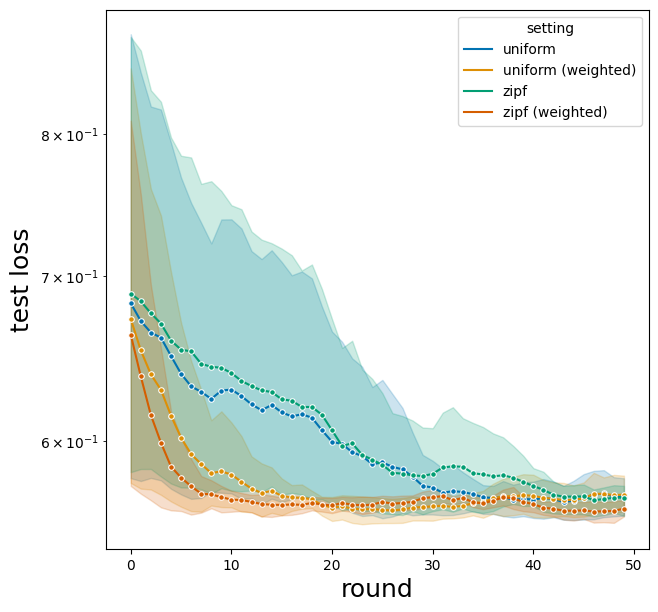

In [29]:
# tcga_brca

setting_map = {0: "uniform", 1: "uniform (weighted)", 2: "zipf", 3: "zipf (weighted)"}


file_paths = [
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/1967cc0ede/sim-20230721224930-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/24948bb907/sim-20230721230820-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/6235614e8a/sim-20230721232506-results.json",
    "/Users/fumiyuki/research/AcSilo/acsilo/exp/results/425b124467/sim-20230721234131-results.json",
]

plot_multiple_losses(file_paths, setting_map)
# plot_multiple_metrics(file_paths, setting_map)
# plot_multiple_epsilons(file_paths, setting_map)

## Privacy-utility
- mnist
- creditcard
- tcga_brca
- heart_disease